**REMOVING TREND & SEASONALITY**

In [2]:
import pandas as pd

In [5]:
df = pd.read_csv('us-airlines-monthly-aircraft-miles-flown.csv', header = 0, parse_dates=[0])
df.head()

,Month,MilesMM
0,1963-01-01,6827
1,1963-02-01,6178
2,1963-03-01,7084
3,1963-04-01,8162
4,1963-05-01,8462


#### REMOVING TREND

In [6]:
df['lag_1']=df['MilesMM'].shift(1)

In [8]:
df['lag_1_diff']=df['MilesMM'].diff(periods=1)
df.head()

,Month,MilesMM,lag_1,lag_1_diff
0,1963-01-01,6827,NaN,NaN
1,1963-02-01,6178,6827.0,-649.0
2,1963-03-01,7084,6178.0,906.0
3,1963-04-01,8162,7084.0,1078.0
4,1963-05-01,8462,8162.0,300.0


In [10]:
df.index=df['Month']
df.head()

,Month,MilesMM,lag_1,lag_1_diff
Month,,,,
1963-01-01,1963-01-01,6827,NaN,NaN
1963-02-01,1963-02-01,6178,6827.0,-649.0
1963-03-01,1963-03-01,7084,6178.0,906.0
1963-04-01,1963-04-01,8162,7084.0,1078.0
1963-05-01,1963-05-01,8462,8162.0,300.0


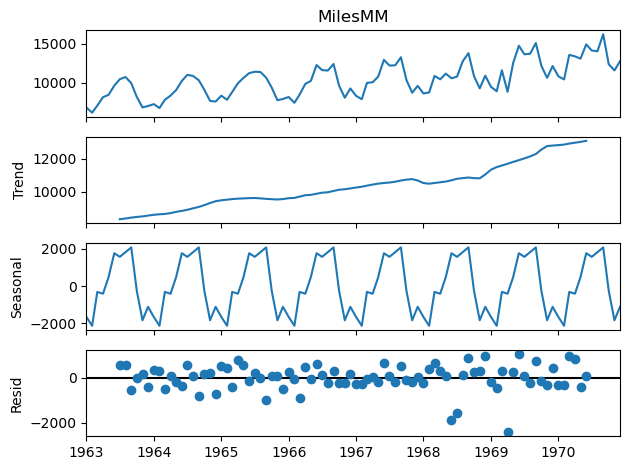

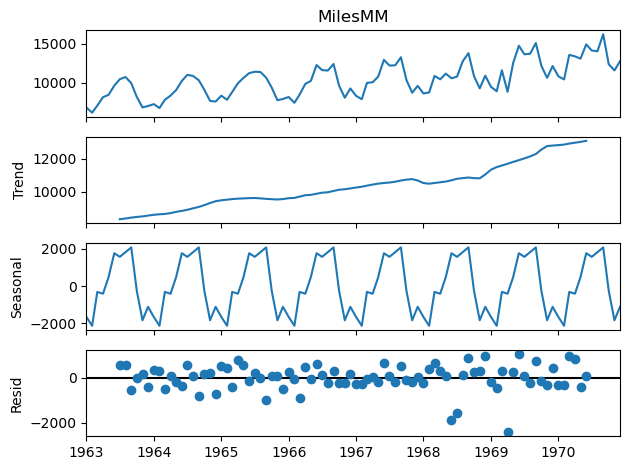

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
decompose1 = seasonal_decompose(df['MilesMM'], model = 'additive')
decompose1.plot()

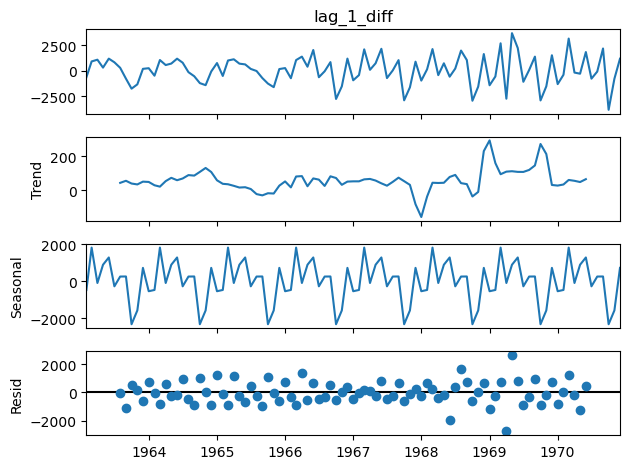

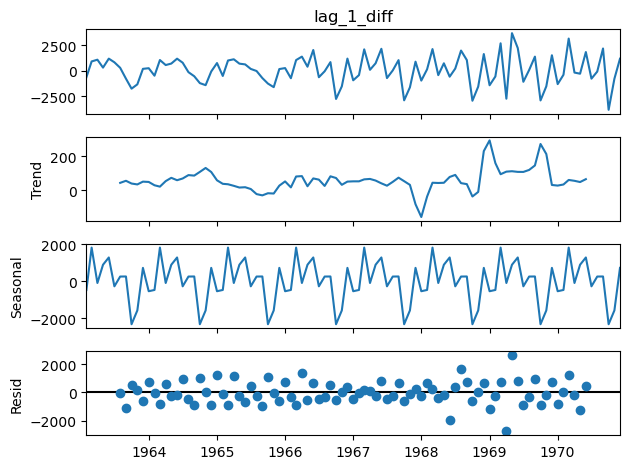

In [16]:
decompose2 = seasonal_decompose(df.iloc[1:,3], model = 'additive')
decompose2.plot()
# iloc[1:,3] starting row is second row and we are plottig the third column

#### REMOVING SEASONALITY

In [17]:
df.head()

,Month,MilesMM,lag_1,lag_1_diff
Month,,,,
1963-01-01,1963-01-01,6827,NaN,NaN
1963-02-01,1963-02-01,6178,6827.0,-649.0
1963-03-01,1963-03-01,7084,6178.0,906.0
1963-04-01,1963-04-01,8162,7084.0,1078.0
1963-05-01,1963-05-01,8462,8162.0,300.0


<Axes: xlabel='Month'>

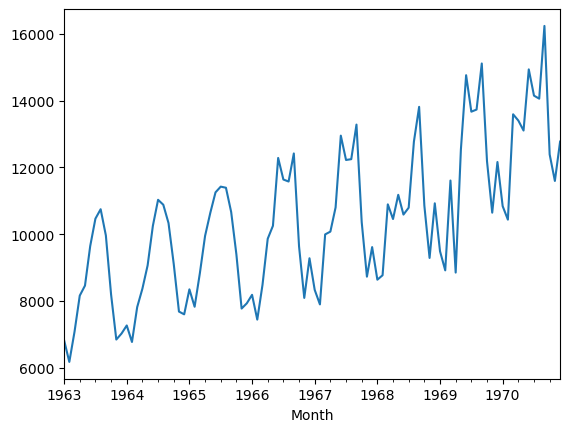

In [20]:
df['MilesMM'].plot()

<Axes: xlabel='Month'>

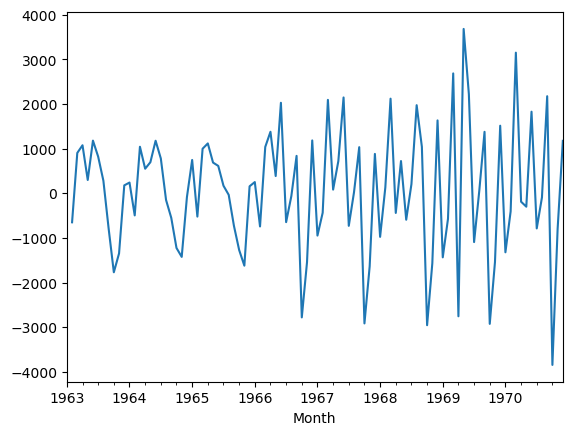

In [18]:
df['lag_1_diff'].plot()

<Axes: xlabel='Month'>

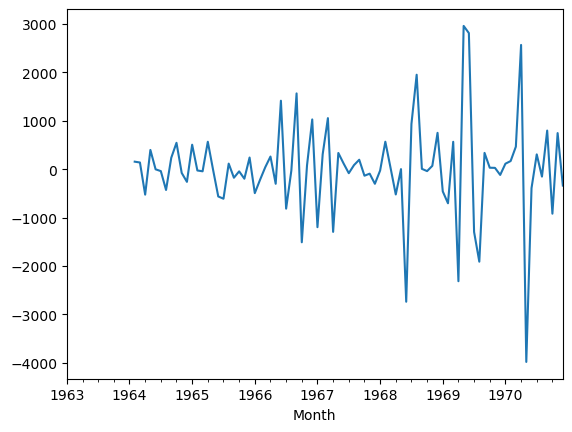

In [21]:
df['lag_12_diff']=df['lag_1_diff'].diff(periods=12)
df['lag_12_diff'].plot()

In [22]:
df.head(30)

,Month,MilesMM,lag_1,lag_1_diff,lag_12_diff
Month,,,,,
1963-01-01,1963-01-01,6827,NaN,NaN,NaN
1963-02-01,1963-02-01,6178,6827.0,-649.0,NaN
1963-03-01,1963-03-01,7084,6178.0,906.0,NaN
1963-04-01,1963-04-01,8162,7084.0,1078.0,NaN
1963-05-01,1963-05-01,8462,8162.0,300.0,NaN
1963-06-01,1963-06-01,9644,8462.0,1182.0,NaN
1963-07-01,1963-07-01,10466,9644.0,822.0,NaN
1963-08-01,1963-08-01,10748,10466.0,282.0,NaN
1963-09-01,1963-09-01,9963,10748.0,-785.0,NaN


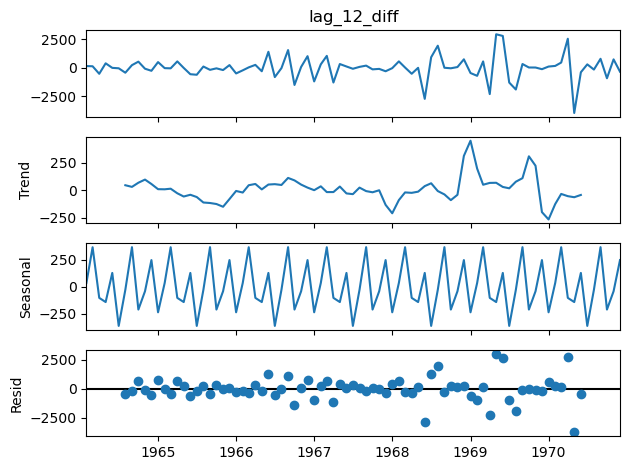

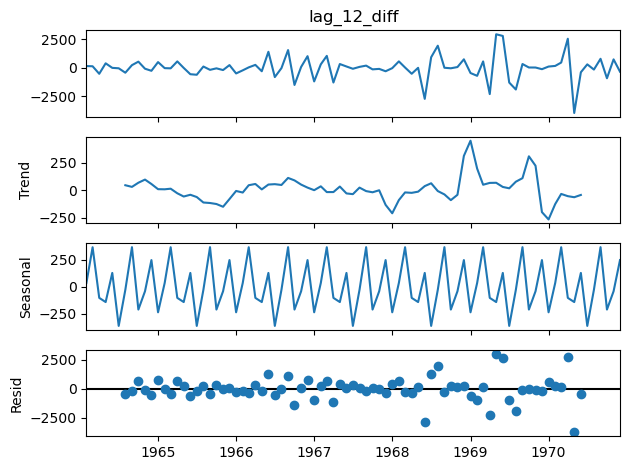

In [24]:
decompose3 = seasonal_decompose(df.iloc[13:,4], model = 'additive')
decompose3.plot()